In [46]:
"""1.This cell contains the code loading,checking and reshaping the dataset for further processing""" 

import torch 
import numpy as np

#Loading Nmpy Arrays from the dataset
raw = np.load("flowers_data.npy")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #Fallback to CPU if GPU is not available
if(device.type == "cuda"):
    print("GPU is available")
    print("Converting Arrays to Tensors . . . .")
    #Converting the numpy arrays to torch tensors for faster computing
converted_x_label = torch.from_numpy(raw['X']).float() #W have converted to float because its necessary for further calculation accuracy
converted_y_label = torch.from_numpy(raw['Y']).float()
print(converted_x_label.shape,converted_x_label.device)
print(converted_y_label.shape,converted_y_label.device)
print("Tensors Created!")

#So the shape becomes (N, H, W, C) where N is the number of samples, H is the height of the image, W is the width of the image and C is the number of channels. But the model we are using expects the input shape to be (N, C, H, W). So we need to permute the dimensions of the tensor to match the input shape of the model.
permuted = torch.permute(converted_x_label, (0, 3, 1, 2)) #Permuting the dimensions of the tensor to match the input shape of the model


GPU is available
Converting Arrays to Tensors . . . .
torch.Size([11197, 150, 150, 3]) cpu
torch.Size([11197]) cpu
Tensors Created!


In [ ]:
"""This cell is used to shuffle the X and Y labels so that the model is 
actually learning and not memorizing the whole dataset

"""
indices = torch.randperm(len(permuted))
X_shuffled = permuted[indices] / 255.0
Y_shuffled = converted_y_label[indices].long().squeeze()


In [ ]:
#This cell splits the shuffled data into Training ans Test sets
#80% of the data is used for training and 20% for testing
train_split = int(0.8 * len(X_shuffled))
X_train = X_shuffled[:train_split]
Y_train = Y_shuffled[:train_split]
X_test = X_shuffled[train_split:]
Y_test = Y_shuffled[train_split:] 
print(len(X_train),len(Y_train),len(X_test),len(Y_test))



8957 8957 2240 2240


In [ ]:
from torch.utils.data import DataLoader,TensorDataset
batch__size = 64
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch__size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=batch__size, shuffle=False)
print(f"Batches created for Train Data:{len(train_loader)} and Test Data: {len(test_loader)}")


Batches created for Train Data:140 and Test Data: 35


In [ ]:
from torch import nn
import torch.optim as optim

class FlowerClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        #Convolutional Layer1 forward pass
        self.cnn_layer = nn.Conv2d(in_channels=3, out_channels =32,kernel_size=3,padding=1,bias = True) 

        #Activation Layer
        self.conv_relu_1 = nn.ReLU()

        #Pooling Layer
        self.pool_1 = nn.MaxPool2d(kernel_size=3,stride =1,padding=1)


        self.cnn_layer_2 = nn.Conv2d(in_channels=32, out_channels =64,kernel_size=3,padding=1,bias = True)
        self.conv_relu_2 = nn.ReLU()
        self.pool_2 = nn.MaxPool2d(kernel_size=3,stride =1,padding=1)




        #Neural Network forward pass
        self.flatten = nn.Flatten()

        self.layer_1 = nn.Linear(in_features = 67500,out_features =128,bias=True)
        self.relu_1 = nn.ReLU()
        self.layer_2 = nn.Linear(in_features=128,out_features=64,bias=True)
        self.relu_2 = nn.ReLU()
        self.layer_3 = nn.Linear(in_features=64,out_features=32,bias=True)
        self.relu_3 = nn.ReLU()

        #Output Layer
        self.out = nn.Linear(in_features = 32, out_features=7)

    

    def forward(self,x):
        x = self.flatten(x)
        x = self.relu_1(self.layer_1(x))
        x = self.relu_2(self.layer_2(x))
        x = self.relu_3(self.layer_3(x))
        x = self.out(x)
        return x

model = FlowerClassifier().to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

FlowerClassifier(
  (cnn_layer): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_relu_1): ReLU()
  (pool_1): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
  (cnn_layer_2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_relu_2): ReLU()
  (pool_2): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer_1): Linear(in_features=67500, out_features=128, bias=True)
  (relu_1): ReLU()
  (layer_2): Linear(in_features=128, out_features=64, bias=True)
  (relu_2): ReLU()
  (layer_3): Linear(in_features=64, out_features=32, bias=True)
  (relu_3): ReLU()
  (out): Linear(in_features=32, out_features=7, bias=True)
)


In [ ]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

epochs = 20

for epoch in range(epochs):

    model.train()
    

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass & loss
        output = model(images)
        loss = loss_function(output, labels)

        # Optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(output, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    # Step 3: Now both variables exist and can be safely divided
    train_loss = running_train_loss / total_train
    train_acc = (correct_train / total_train) * 100


    model.eval()
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.inference_mode():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            test_output = model(images)
            t_loss = loss_function(test_output, labels)

            running_test_loss += t_loss.item() * images.size(0)
            _, test_preds = torch.max(test_output, 1)
            correct_test += (test_preds == labels).sum().item()
            total_test += labels.size(0)

    test_loss = running_test_loss / total_test
    test_acc = (correct_test / total_test) * 100

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch [01/20] | Train Loss: 1.6866 | Train Acc: 33.93% | Test Loss: 1.4998 | Test Acc: 43.21%
Epoch [02/20] | Train Loss: 1.4496 | Train Acc: 46.04% | Test Loss: 1.4739 | Test Acc: 44.51%
Epoch [03/20] | Train Loss: 1.3421 | Train Acc: 50.23% | Test Loss: 1.3171 | Test Acc: 51.83%
Epoch [04/20] | Train Loss: 1.2611 | Train Acc: 53.38% | Test Loss: 1.3530 | Test Acc: 48.26%
Epoch [05/20] | Train Loss: 1.2223 | Train Acc: 55.29% | Test Loss: 1.2706 | Test Acc: 52.14%
Epoch [06/20] | Train Loss: 1.1759 | Train Acc: 56.84% | Test Loss: 1.2623 | Test Acc: 53.44%
Epoch [07/20] | Train Loss: 1.1324 | Train Acc: 58.36% | Test Loss: 1.3191 | Test Acc: 51.21%
Epoch [08/20] | Train Loss: 1.1051 | Train Acc: 59.28% | Test Loss: 1.2761 | Test Acc: 55.27%
Epoch [09/20] | Train Loss: 1.0730 | Train Acc: 60.32% | Test Loss: 1.2932 | Test Acc: 53.48%
Epoch [10/20] | Train Loss: 1.0312 | Train Acc: 61.59% | Test Loss: 1.2642 | Test Acc: 53.75%
Epoch [11/20] | Train Loss: 1.0308 | Train Acc: 62.35% | Tes

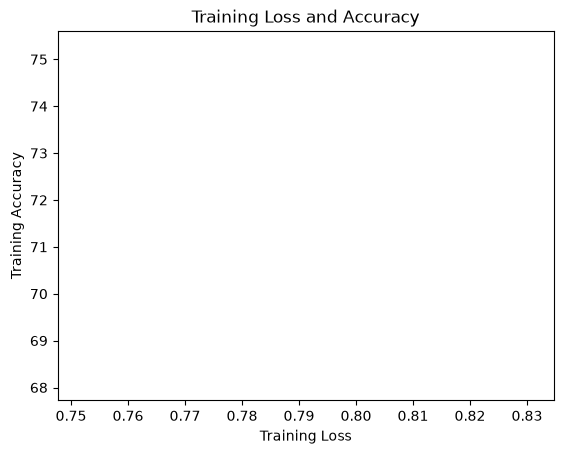

In [ ]:
import matplotlib.pyplot as pt
pt.plot(train_loss,train_acc)
pt.title("Training Loss and Accuracy")
pt.xlabel("Training Loss")
pt.ylabel("Training Accuracy")

pt.show()